**Plan**

**<h2>1. Inférence et raisonnement avec les LLMs</h2>**

**<h2>2. Gestion et utilisation de la mémoire avec les LLMs</h2>**

**<h2>3. Prise en compte du contexte avec les LLMs</h2>**

**<h2>4. Retrieval-Augmented Generation (RAG) avec les LLMs</h2>**


# **1. Inférence et raisonnement avec les LLMs**


Les **LLMs** (Large Language Models) sont construits à partir du **decoder des Transformers** et sont des **modèles génératifs** qui apprennent à modéliser la **probabilité jointe d’une séquence de tokens** :

$$
P(x_1, x_2, ..., x_T) = \prod_{t=1}^{T} P(x_t \mid x_1, ..., x_{t-1})
$$

Autrement dit, ils prédisent chaque token **conditionnellement sur tous les tokens précédents**.

Lors de l’**inférence**, la génération de texte peut être contrôlée par différentes stratégies :

- **Greedy decoding** : on choisit à chaque étape le token ayant la **probabilité maximale**, ce qui est rapide mais peut produire des sorties répétitives.
- **Sampling** : on tire le token **aléatoirement selon sa distribution prédite**, ce qui introduit de la diversité.
- **Top-k / Top-p sampling** : on limite le tirage aux k tokens les plus probables ou aux tokens dont la probabilité cumulée atteint p, pour éviter les choix improbables.
- **Temperature** : on ajuste la “confiance” du modèle ; une température plus élevée rend la distribution plus **plate**, favorisant la diversité, et une température plus basse rend la génération plus **conservatrice**.

Ces techniques permettent de **contrôler la créativité et la cohérence** des LLMs pendant la génération de texte.


## **A. Charger le LLM en local**


Charger un **LLM en local** signifie exécuter directement le modèle sur sa propre machine (GPU/CPU), sans passer par une API distante.
Cette approche offre **un contrôle total** (confidentialité, personnalisation, latence), mais elle est **coûteuse en ressources** : un modèle comme _Mistral-7B_ nécessite plusieurs **Go de mémoire GPU**, même avec des techniques de **quantification**. Elle est donc principalement utilisée pour la recherche, l’expérimentation ou les environnements disposant de GPU adaptés.


In [ ]:
# 1. Installer les dépendances (GPU obligatoire)

! pip install -U transformers accelerate bitsandbytes

- **accelerate** : gestion automatique du placement CPU/GPU
- **bitsandbytes** : quantification (4-bit / 8-bit) pour réduire l’empreinte mémoire


In [2]:
# 2. Importer les dépendances

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [3]:
# 3. Définir la stratégie de quantification

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

> Sans quantification (`bnb_config=None`), le modèle est plus précis mais **beaucoup plus gourmand en mémoire**.


In [ ]:
# 4. Charger le modèle et le tokenizer

HF_TOKEN = None
READER_MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.1"

model = AutoModelForCausalLM.from_pretrained(
    READER_MODEL_NAME, quantization_config=bnb_config, token=HF_TOKEN, device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(READER_MODEL_NAME, token=HF_TOKEN)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

In [ ]:
# 5. Inférence

prompt = "Explain what inference means in large language models."

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=500,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
    )

generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
generated_text

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


"Explain what inference means in large language models.\nInference is a process used in large language models to generate text based on a given prompt or input. It involves using the model's knowledge and understanding of language to make educated guesses about the most likely next words in a sequence, given the context and the information provided in the input. Inference is a critical component of natural language processing and is used in a wide range of applications, including language translation, speech recognition, and text generation. In large language models, inference is typically performed using a process called sampling, which involves randomly selecting a subset of the model's parameters to generate a sample of text. The quality of the generated text depends on the quality of the model's parameters and the effectiveness of the sampling process."

## **B. Utiliser le LLM via une API**


Plutôt que de charger un LLM en local, il est souvent plus simple et plus économique de consommer un modèle via une API. Dans ce cas, le modèle est hébergé sur des serveurs distants, et l’utilisateur envoie simplement une requête (prompt) au modèle, qui renvoie une réponse générée.
Cette approche permet de réduire drastiquement les coûts matériels, d’accéder à des modèles plus puissants et d’éviter la gestion de l’infrastructure (GPU, mémoire, mise à jour des modèles). En contrepartie, elle introduit une dépendance à un service externe et des considérations de coût à l’usage et de confidentialité.

OpenRouter est une plateforme qui agit comme une couche d’unification au-dessus de plusieurs fournisseurs de LLMs (OpenAI, DeepSeek, Mistral, etc.). Elle permet d’accéder à différents modèles via une API unique, simplement en changeant le nom du modèle dans la requête.


In [1]:
# 1. Importer les dépendances

import requests
import json

In [4]:
# 2. Envoyer la requête

import os
OPEN_ROUTER_TOKEN = "Bearer " + os.getenv("OPENROUTER_TOKEN", "")
response = requests.post(
    url="https://openrouter.ai/api/v1/chat/completions",
    headers={
        "Authorization": OPEN_ROUTER_TOKEN,
        "Content-Type": "application/json",
        # "HTTP-Referer": "<YOUR_SITE_URL>", # Optional. Site URL for rankings on openrouter.ai.
        # "X-Title": "<YOUR_SITE_NAME>", # Optional. Site title for rankings on openrouter.ai.
    },
    data=json.dumps(
        {
            "model": "nvidia/nemotron-3-nano-30b-a3b:free",  # "openrouter/free"
            "messages": [
                {
                    "role": "user",
                    "content": "Explain what inference means in large language models.",
                }
            ],
        }
    ),
)

In [5]:
# 3. Récupérer et afficher le résultat

if response.status_code == 200:
    result = response.json()
    answer = result["choices"][0]["message"]["content"]
    print("Réponse du modèle :", answer)
else:
    print("Erreur :", response.status_code, response.text)

Réponse du modèle : **Inference** is the phase of a large language model (LLM) where the model is used to generate new text (or other output) from a given prompt.  
It is the “run‑time” counterpart to the **training** phase, where the model learns patterns from massive amounts of data. Below is a layered explanation that covers the conceptual idea, the mechanics at the token level, the typical workflow, and some practical nuances (hardware, speed tricks, etc.).

---

## 1. High‑level definition  | Aspect | Training | Inference |
|--------|----------|-----------|
| **Goal** | Adjust millions‑to‑hundreds‑of‑billions of weights so that the model predicts the next token correctly on a massive corpus. | Use the learned weights to produce a sensible continuation (or answer, translation, code, etc.) for a *specific* input prompt. |
| **Data flow** | Forward‑pass → loss computation → backward‑pass → weight update (many‑step optimization). | Forward‑pass only (no gradients). |
| **Compute** | G

# **2. Gestion et utilisation de la mémoire avec les LLMs**


Par défaut, les **LLMs n’ont pas de mémoire persistante**. Chaque requête est traitée **indépendamment**, et le modèle n’a accès qu’au **contexte qui lui est fourni dans l’entrée** (le prompt ou la liste de messages). Une fois la génération terminée, le modèle **n’“oublie” pas au sens humain**, mais il **ne conserve aucune information** pour les appels suivants.

Cependant, il est possible de **simuler une mémoire** en réinjectant explicitement des informations passées dans le contexte d’entrée. Cette mémoire est donc **externe au modèle** et gérée par l’application (code, base de données, historique de conversation).

---

Types de mémoire couramment utilisés

- **Mémoire de conversation** : historique des échanges utilisateur–assistant.
- **Mémoire courte** : résumé des derniers tours de dialogue.
- **Mémoire longue** : informations persistantes (profil utilisateur, préférences).
- **Mémoire structurée** : faits stockés sous forme clé–valeur ou base vectorielle (préfigure le RAG).


In [6]:
import requests
import json

import os
OPEN_ROUTER_TOKEN = "Bearer " + os.getenv("OPENROUTER_TOKEN", "")
URL = "https://openrouter.ai/api/v1/chat/completions"
HEADERS = {
    "Authorization": OPEN_ROUTER_TOKEN,
    "Content-Type": "application/json",
}

model_name = "nvidia/nemotron-3-nano-30b-a3b:free"
conversation = []

In [7]:
conversation.append({"role": "user", "content": "Quelle est la capitale de la France?"})

response = requests.post(
    url=URL,
    headers=HEADERS,
    data=json.dumps(
        {
            "model": model_name,
            "messages": conversation,
        }
    ),
)

data = response.json()
if "choices" not in data:
    raise RuntimeError(f"API error {response.status_code}: {data}")
answer_1 = data["choices"][0]["message"]["content"]
conversation.append({"role": "assistant", "content": answer_1})

print("Assistant:", answer_1)

Assistant: Paris


In [8]:
conversation.append({"role": "user", "content": "Qui est le président?"})

response = requests.post(
    url=URL,
    headers=HEADERS,
    data=json.dumps(
        {
            "model": model_name,
            "messages": conversation,
        }
    ),
)

answer_2 = response.json()["choices"][0]["message"]["content"]
conversation.append({"role": "assistant", "content": answer_2})

print("Assistant:", answer_2)

Assistant: Le président en fonction actuellement est **Emmanuel Macron**.


In [9]:
conversation.append({"role": "user", "content": "Combien de mandats a-t-il effectués?"})

response = requests.post(
    url=URL,
    headers=HEADERS,
    data=json.dumps(
        {
            "model": model_name,
            "messages": conversation,
        }
    ),
)

answer_3 = response.json()["choices"][0]["message"]["content"]
conversation.append({"role": "assistant", "content": answer_3})

print("Assistant:", answer_3)

Assistant: Emmanuel Macron a été élu pour la première fois en **2017** et a donc accompli un mandat complet (de 2017 à 2022). Il s’est ensuite présenté à l’élection présidentielle de **2022** et a été réélu, ce qui marque le début de son **deuxième mandat**, qui a démarré le 14 mai 2022 et doit se poursuivre jusqu’en 2027.

En résumé :  - **Mandat complet terminé** : 1 (de 2017‑2022)  
- **Mandat en cours** : 2ᵉ mandat (depuis le 14 mai 2022)  

Ainsi, il a déjà **terminé un mandat** et est **en cours de second mandat**.


# **3. Prise en compte du contexte avec les LLMs**


Le **contexte** désigne l’ensemble des informations fournies au modèle **au moment de l’inférence**, indépendamment de toute interaction passée. Contrairement à la mémoire conversationnelle, le contexte est **statique** : il est injecté directement dans le prompt et sert à **contraindre, orienter ou enrichir la réponse** du LLM.

Les LLMs ne disposent pas d’une compréhension du monde en temps réel. Ils produisent leurs réponses uniquement à partir :

- des connaissances apprises lors de l’entraînement,
- **du contexte textuel fourni dans l’entrée**.

Fournir un contexte explicite permet donc :

- de **réduire l’ambiguïté**,
- d’**actualiser** ou de **corriger** certaines informations,
- de **forcer le modèle à raisonner à partir d’un cadre précis**.


In [11]:
import requests
import json

import os
OPEN_ROUTER_TOKEN = "Bearer " + os.getenv("OPENROUTER_TOKEN", "")

response = requests.post(
    url="https://openrouter.ai/api/v1/chat/completions",
    headers={
        "Authorization": OPEN_ROUTER_TOKEN,
        "Content-Type": "application/json",
    },
    data=json.dumps(
        {
            "model": "nvidia/nemotron-3-nano-30b-a3b:free",
            "messages": [
                {
                    "role": "system",
                    "content": (
                        "Contexte : Emmanuel Macron est le président de la République française. "
                        "Il exerce actuellement son deuxième mandat présidentiel, entamé en 2022. "
                        "La durée d’un mandat présidentiel en France est de cinq ans."
                    ),
                },
                {
                    "role": "user",
                    "content": (
                        "En tenant compte uniquement du contexte fourni, "
                        "jusqu’à quelle année Emmanuel Macron exercera-t-il son mandat actuel ?"
                    ),
                },
            ],
        }
    ),
)

In [12]:
if response.status_code == 200:
    result = response.json()
    answer = result["choices"][0]["message"]["content"]
    print("Réponse du modèle :", answer)
else:
    print("Erreur :", response.status_code, response.text)

Réponse du modèle : Ense basant uniquement sur le contexte fourni, Emmanuel Macron exercera son mandat actuel jusqu’en 2027. (Son deuxième mandat de cinq ans a débuté en 2022.)


# **4. Retrieval-Augmented Generation (RAG) avec les LLMs**


Le **Retrieval-Augmented Generation (RAG)** est une approche qui combine un **LLM génératif** avec un **mécanisme de recherche externe**. Au lieu de s’appuyer uniquement sur ses connaissances internes, le modèle commence par **récupérer des documents pertinents** (par exemple à partir d’une base de données, de fichiers ou d’un moteur de recherche), puis **génère une réponse en s’appuyant sur ces informations récupérées**, intégrées comme contexte dans le prompt. Le RAG permet ainsi de **réduire les hallucinations**, d’**actualiser les réponses** et d’exploiter des **connaissances spécifiques ou privées**, sans réentraîner le modèle.


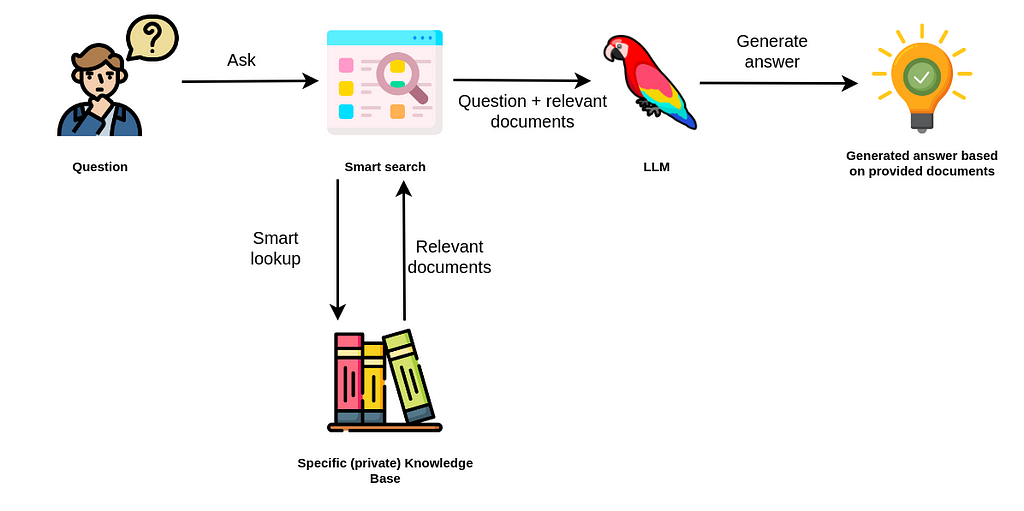


In [1]:
! pip install -q langchain langchain-community sentence-transformers faiss-cpu openpyxl pacmap pypdf


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


**<h3>1. Charger les données</h3>**


In [3]:
# Note Importante: Mettre tous les fichiers dans le répertoire sepsis

from urllib.request import urlopen, Request
from urllib.error import HTTPError, URLError
import os
import time
from langchain_community.document_loaders import PyPDFDirectoryLoader

# --- Liste de fichiers : URLs ou chemins locaux ---
files = [
    "finance/finance1.pdf",  # Diagnosis and management
    "finance/finance2.pdf",  # Clinical features
    # "https://example.com/some.pdf",  # URL exemple
]

DEST_FOLDER = "finance"
os.makedirs(DEST_FOLDER, exist_ok=True)


# --- Fonction universelle pour récupérer un fichier ---
def fetch_file(path_or_url, dest_folder=DEST_FOLDER, retries=3, delay=5):
    """
    Télécharge un fichier s'il s'agit d'une URL, ou retourne directement le chemin
    si le fichier est déjà local.
    """
    os.makedirs(dest_folder, exist_ok=True)

    # Cas URL
    if path_or_url.startswith("http://") or path_or_url.startswith("https://"):
        file_name = path_or_url.split("/")[-1]
        file_path = os.path.join(dest_folder, file_name)

        # Si le fichier existe déjà, on le réutilise
        if os.path.exists(file_path):
            print(f"{file_path} already exists, skipping download.")
            return file_path

        # Tentatives de téléchargement
        for attempt in range(retries):
            try:
                req = Request(path_or_url, headers={"User-Agent": "Mozilla/5.0"})
                with urlopen(req) as response, open(file_path, "wb") as out_file:
                    out_file.write(response.read())
                print(f"Successfully downloaded {file_path}")
                return file_path
            except HTTPError as e:
                print(
                    f"HTTP Error: {e.code} for {path_or_url}. Retrying in {delay}s..."
                )
            except URLError as e:
                print(
                    f"URL Error: {e.reason} for {path_or_url}. Retrying in {delay}s..."
                )
            except Exception as e:
                print(
                    f"Unexpected error: {e} for {path_or_url}. Retrying in {delay}s..."
                )
            time.sleep(delay)

        print(f"Failed to download {path_or_url} after {retries} attempts.")
        return None

    # Cas fichier local
    elif os.path.exists(path_or_url):
        print(f"Loading local file: {path_or_url}")
        return path_or_url
    else:
        print(f"File does not exist: {path_or_url}")
        return None


# --- Récupération de tous les fichiers ---
all_files = []
for f in files:
    local_path = fetch_file(f)
    if local_path:
        all_files.append(local_path)

print(f"Total files ready: {len(all_files)}")

# --- Charger tous les PDF avec LangChain ---
loader = PyPDFDirectoryLoader(DEST_FOLDER)
docs_before_split = loader.load()

# Calcul de la taille moyenne des documents
avg_doc_length = lambda docs: sum([len(doc.page_content) for doc in docs]) // len(docs)
avg_char_before_split = avg_doc_length(docs_before_split)

print(
    f"Before split, there were {len(docs_before_split)} documents loaded, "
    f"with average characters equal to {avg_char_before_split}."
)

Loading local file: finance/finance1.pdf
Loading local file: finance/finance2.pdf
Total files ready: 2
Before split, there were 31 documents loaded, with average characters equal to 1740.


In [4]:
# A list of dict
print(docs_before_split[0].page_content)

LES ESSENTIELS 
DE L'ÉDUCATION FINANCIÈRE
Ressources pédagogiques
INC 2023


**<h3>2. Création de chunks</h3>**


Un **chunk** est simplement un **morceau de texte** extrait d’un document plus long. Les LLMs ont une **limite de contexte** : ils ne peuvent traiter qu’un certain nombre de tokens (ou caractères) à la fois.

Créer des chunks permet donc de :

1. **Diviser les documents volumineux** pour que chaque portion tienne dans la fenêtre de contexte du modèle.
2. **Améliorer la recherche et le RAG** : chaque chunk devient une unité indépendante que l’on peut indexer et retrouver facilement selon sa pertinence.
3. **Limiter les pertes d’information** : plutôt que tronquer un document entier, on le découpe pour garder toutes les informations importantes réparties sur plusieurs morceaux.


**<h4>A. CharacterTextSplitter:</h3>**


Le `CharacterTextSplitter` divise le texte en segments plus petits en utilisant une approche **basée sur les caractères** :

1. **Initialisation** : Définir la taille maximale d’un segment et les séparateurs (ex : espace, virgule).
2. **Analyse du texte** : Parcourir le texte de manière linéaire, caractère par caractère.
3. **Vérification des séparateurs** : Identifier si le caractère actuel est un séparateur.
4. **Création du segment** : Créer un nouveau segment à chaque séparateur ou lorsque la longueur maximale est atteinte.
5. **Gestion de la longueur maximale** : Si le texte entre deux séparateurs dépasse la longueur maximale, couper le segment même au milieu d’un mot.
6. **Collecte des segments** : Ajouter chaque segment dans une liste.
7. **Finalisation** : Retourner tous les segments après traitement.


In [5]:
from langchain_text_splitters import CharacterTextSplitter

texte = (
    "Les modèles de langage (LLMs) sont des outils puissants. "
    "Ils permettent de générer du texte, de résumer, et même de raisonner sur des informations. "
    "Cependant, chaque modèle a une limite de contexte."
)

# Création du splitter
splitter = CharacterTextSplitter(
    separator=" ",  # séparer par espace
    chunk_size=50,  # longueur maximale d'un segment
    chunk_overlap=0,  # pas de chevauchement
)

# Découpage en chunks
chunks = splitter.split_text(texte)

for i, chunk in enumerate(chunks, 1):
    print(f"Chunk {i} ({len(chunk)} chars): {chunk}")

# puissants est écarté car s'il est pris en compte sur chunk 1, le nombre de charactères dépasse 50.

Chunk 1 (45 chars): Les modèles de langage (LLMs) sont des outils
Chunk 2 (49 chars): puissants. Ils permettent de générer du texte, de
Chunk 3 (37 chars): résumer, et même de raisonner sur des
Chunk 4 (44 chars): informations. Cependant, chaque modèle a une
Chunk 5 (19 chars): limite de contexte.


**<h4>B. RecursiveCharacterTextSplitter</h4>**


L’algorithme **RecursiveCharacterTextSplitter** divise le texte de manière **récursive** en utilisant une liste de séparateurs spécifiés :

1. **Initialisation** : Configurer les séparateurs et les paramètres optionnels comme la longueur maximale d’un segment.
2. **Découpage récursif** : Parcourt le texte en recherchant itérativement le premier séparateur de la liste.
3. **Division du texte** : Coupe le texte au niveau du séparateur, en faisant de la première partie un segment.
4. **Récursion** : Continue à découper le reste du texte de manière récursive, en recherchant les séparateurs suivants.
5. **Assemblage des résultats** : Ajoute chaque segment identifié à une liste.
6. **Résultat final** : Retourne tous les segments collectés après que toute la récursion soit terminée.


In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

texte = (
    "Les modèles de langage (LLMs) sont des outils puissants.\n"
    "Ils permettent de générer du texte, de résumer, et même de raisonner sur des informations.\n"
    "Cependant, chaque modèle a une limite de contexte."
)

# Création du splitter
splitter = RecursiveCharacterTextSplitter(
    separators=["\n", " "],  # séparer par espace
    chunk_size=50,  # longueur maximale d'un segment
    chunk_overlap=0,  # pas de chevauchement
)

# Découpage en chunks
chunks = splitter.split_text(texte)

for i, chunk in enumerate(chunks, 1):
    print(f"Chunk {i} ({len(chunk)} chars): {chunk}")

Chunk 1 (45 chars): Les modèles de langage (LLMs) sont des outils
Chunk 2 (10 chars): puissants.
Chunk 3 (47 chars): Ils permettent de générer du texte, de résumer,
Chunk 4 (42 chars): et même de raisonner sur des informations.
Chunk 5 (40 chars): Cependant, chaque modèle a une limite de
Chunk 6 (9 chars): contexte.


**<h4>C. SemanticChunker</h4>**


1. **Initialisation** : Définir les paramètres comme la longueur maximale d’un segment, les séparateurs, et les modèles NLP pour l’analyse du texte.
2. **Analyse du texte** : Analyser le texte à l’aide de techniques NLP pour identifier les phrases, propositions, paragraphes ou sections thématiques.
3. **Détection des unités sémantiques** : Identifier des unités significatives afin que les segments soient cohérents et pertinents contextuellement.
4. **Création des segments** : Diviser le texte en segments basés sur les unités sémantiques identifiées, en évitant les coupures arbitraires.
5. **Utilisation des modèles NLP** : Exploiter les modèles NLP pour améliorer le découpage, en utilisant des analyseurs syntaxiques, des détecteurs de fin de phrase ou des reconnaisseurs thématiques.
6. **Assemblage des segments** : Rassembler les segments dans une liste ou une autre structure.
7. **Finalisation** : Retourner tous les segments sémantiquement cohérents après l’analyse et le découpage.


In [7]:
! pip install --quiet langchain_experimental
! pip install langchain-community
! pip install sentence_transformers


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [9]:
from langchain_community.embeddings import HuggingFaceBgeEmbeddings

texte = (
    "Les modèles de langage (LLMs) sont des outils puissants. "
    "Ils permettent de générer du texte, de résumer, et même de raisonner sur des informations. "
    "La capitale de la France est Paris. "
    "Le président actuel est Emmanuel Macron. "
    "Cependant, chaque modèle a une limite de contexte. "
    "Certains modèles utilisent des techniques RAG pour améliorer la précision. "
    "Les embeddings permettent de mesurer la similarité entre textes."
)


huggingface_embeddings = HuggingFaceBgeEmbeddings(
    model_name="sentence-transformers/all-MiniLM-l6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

from langchain_experimental.text_splitter import SemanticChunker

splitter = SemanticChunker(
    huggingface_embeddings,
    breakpoint_threshold_type="percentile",  # peut être remplacé par "standard_deviation", "interquartile" or "gradient"
)
# Découpage en chunks
chunks = splitter.split_text(texte)

for i, chunk in enumerate(chunks, 1):
    print(f"Chunk {i} ({len(chunk)} chars): {chunk}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11088.92it/s]


Chunk 1 (147 chars): Les modèles de langage (LLMs) sont des outils puissants. Ils permettent de générer du texte, de résumer, et même de raisonner sur des informations.
Chunk 2 (267 chars): La capitale de la France est Paris. Le président actuel est Emmanuel Macron. Cependant, chaque modèle a une limite de contexte. Certains modèles utilisent des techniques RAG pour améliorer la précision. Les embeddings permettent de mesurer la similarité entre textes.


**<h3>3. Création de base de données vectorielle</h3>**


In [10]:
! pip install -U langchain-huggingface


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [11]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=512,  # max input lenght of our tokenizer
    chunk_overlap=512 // 10,
)
# Return list
docs_after_split = text_splitter.split_documents(docs_before_split)
avg_char_after_split = avg_doc_length(docs_after_split)
print(
    f"After split, there were {len(docs_after_split)} documents (chunks), with average characters equal to {avg_char_after_split} (average chunk length)."
)

After split, there were 131 documents (chunks), with average characters equal to 419 (average chunk length).


In [12]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import torch
from langchain_community.vectorstores import FAISS
import faiss

# Embedder
EMBEDDING_MODEL_NAME = "thenlper/gte-small"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    multi_process=True,
    model_kwargs={"device": device},
    encode_kwargs={"normalize_embeddings": True},  # set True for cosine similarity
)

# Sauvegarder les données dans la base
KNOWLEDGE_VECTOR_DATABASE = FAISS.from_documents(
    docs_after_split, embedding_model, distance_strategy=DistanceStrategy.COSINE
)

# Test the embedder
user_query = "What is the estimated incidence of severe sepsis and septic shock in European and US hospitals?"
query_vector = embedding_model.embed_query(user_query)
print(f"A list of size : {len(query_vector)}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8867.36it/s]


A list of size : 384


In [13]:
# Enrégistrer les Embeddings
KNOWLEDGE_VECTOR_DATABASE.save_local("faiss_index")
# Recharger les Embeddings
KNOWLEDGE_VECTOR_DATABASE = FAISS.load_local(
    "faiss_index", embedding_model, allow_dangerous_deserialization=True
)

In [14]:
# Test la récupération
print(f"\nStarting retrieval for {user_query=}...")
retrieved_docs = KNOWLEDGE_VECTOR_DATABASE.similarity_search(query=user_query, k=5)

print(
    "\n==================================Top document=================================="
)

print(retrieved_docs[0].page_content)

print("==================================Metadata==================================")

print(retrieved_docs[0].metadata)


Starting retrieval for user_query='What is the estimated incidence of severe sepsis and septic shock in European and US hospitals?'...

==================================Top document==================================
Autre dépenses3.7%
Santé2.8%
4
Faites vos calculs
==================================Metadata==================================
{'producer': 'Canva', 'creator': 'Canva', 'creationdate': '2023-03-14T08:45:24+00:00', 'keywords': 'DAFaKqIq_hY,BACsEo4tcSI', 'author': 'REFKA AZAIEZ', 'title': 'Guide', 'source': 'finance/finance2.pdf', 'total_pages': 21, 'page': 3, 'page_label': '4'}


**<h3>4. LLM répond en se basant sur le contexte récupéré</h3>**


In [15]:
from wsgiref import headers

import requests
import json

# --- Query utilisateur ---
user_query = "What is the estimated incidence of severe sepsis and septic shock in European and US hospitals?"

# --- Récupération des docs depuis FAISS ---
print(f"\nStarting retrieval for {user_query=}")
retrieved_docs = KNOWLEDGE_VECTOR_DATABASE.similarity_search(query=user_query, k=5)

# Concaténer le contenu des documents
context_text = "\n".join([doc.page_content for doc in retrieved_docs])
print("\n===== Retrieved Context (first 1000 chars) =====")
# print(context_text[:1000])  # pour vérification

# --- Appel à OpenRouter avec contexte imposé et rôle d'expert ---
import os
OPEN_ROUTER_TOKEN = "Bearer " + os.getenv("OPENROUTER_TOKEN", "")

response = requests.post(
    url="https://openrouter.ai/api/v1/chat/completions",
    headers={
        "Authorization": OPEN_ROUTER_TOKEN,
        "Content-Type": "application/json",
    },
    data=json.dumps(
        {
            "model": "nvidia/nemotron-3-nano-30b-a3b:free",
            "messages": [
                {
                    "role": "system",
                    "content": (
                        f"You are a medical expert specialized in sepsis and critical care. "
                        f"You MUST answer the user's questions ONLY using the following context extracted from trusted medical documents. "
                        f"Do NOT provide any information that is not contained in this context.\n\n"
                        f"Context:\n{context_text}"
                    ),
                },
                {"role": "user", "content": user_query},
            ],
        }
    ),
)

# --- Affichage de la réponse ---
if response.status_code == 200:
    answer = response.json()
    print("\n===== Model Response =====")
    print(answer["choices"][0]["message"]["content"])
else:
    print("Error:", response.status_code, response.text)


Starting retrieval for user_query='What is the estimated incidence of severe sepsis and septic shock in European and US hospitals?'



===== Retrieved Context (first 1000 chars) =====

===== Model Response =====
I’m sorry, but the provided context does not contain any information about the estimated incidence of severe sepsis or septic shock in European or US hospitals. Consequently, I cannot answer that question based solely on the given material.


**<h3>5. Reranking</h3>**


**Reranking** is a process used in information retrieval and RAG systems to improve the relevance of retrieved documents. After an initial retrieval step, where a set of candidate documents or passages is selected based on similarity to the query, a reranker evaluates these candidates more carefully, often using more sophisticated models such as transformers or cross-encoders. The reranker assigns a new relevance score to each document, prioritizing those that are most likely to contain accurate and contextually useful information. This step helps ensure that the model generates answers based on the **most pertinent and high-quality sources**, reducing noise from less relevant documents.


In [16]:
from sentence_transformers import CrossEncoder, util

# Initialize cross-encoder reranker
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")


def rerank_docs(question, docs, top_k=2):
    # Compute relevance scores
    scores = reranker.predict([(question, doc) for doc in docs])
    # Sort docs by score descending
    sorted_docs = [doc for _, doc in sorted(zip(scores, docs), reverse=True)]
    return sorted_docs[:top_k]


# Example usage
retrieved_docs = [
    doc.page_content
    for doc in KNOWLEDGE_VECTOR_DATABASE.similarity_search(user_query, k=5)
]
top_docs = rerank_docs(user_query, retrieved_docs)

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 9940.23it/s]


In [17]:
top_docs

['Autre dépenses3.7%\nSanté2.8%\n4\nFaites vos calculs',
 'contactent la direction de l’Éducation financière de la \nBanque de France (1446-EDUCFI-UT@banque-france.fr).\n4  ACPR et AMF, 2020, « L’AMF et l’ACPR mettent en garde le public contre les risques d’arnaques dans le contexte de l’épidémie de coronavirus ».']